# Prediction of Academic Dropout and Academic Success: Comparative Analysis of Machine Learning Models
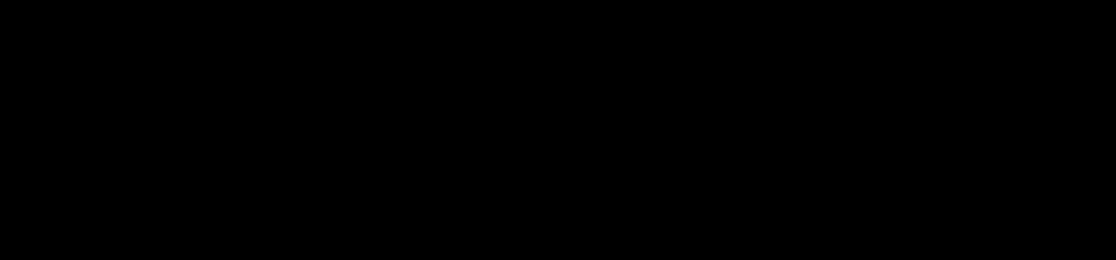

##### _Libraries_

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import seaborn as sns

## EDA
#### **0. Importing Dataset**

In [5]:
data = pd.read_csv('data/raw/data.csv', sep=';')

data.columns = (
    data.columns
    .str.strip()        
    .str.replace('\t', '', regex=False)  
)

Numerical_data = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

print("Dataset Loaded Correctly. Shape:", data.shape)

Dataset Loaded Correctly. Shape: (4424, 37)


##### **1. DESCRIPTIVE STATISTICS AND VISUALIZATIONS**
First, let's analyze the general distribution of our target variable to see if the dataset is balanced, and visualize how some key categorical variables behave.

C:\Users\marin\AppData\Local\Temp\ipykernel_14304\3183524324.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Target', palette='viridis', order=['Dropout', 'Enrolled', 'Graduate'])


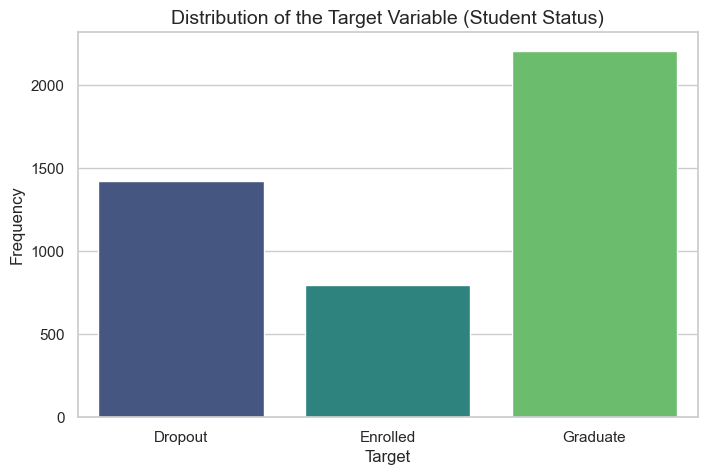

--- Summary Statistics of Categorical Variables ---


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,International
count,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424
unique,6,18,8,17,2,17,21,29,34,32,46,2,2,2,2,2,2,2
top,1,1,1,9500,1,1,1,1,37,9,9,1,0,0,1,0,0,0
freq,3919,1708,3026,766,3941,3717,4314,1069,1209,1577,1010,2426,4373,3921,3896,2868,3325,4314


In [6]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1.1 Distribution of the Target Variable
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Target', palette='viridis', order=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Distribution of the Target Variable (Student Status)', fontsize=14)
plt.xlabel('Target', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# 1.2 Descriptive statistics for categorical variables
# Extract categorical features (those not in Marcos's Numerical_data list and not the Target)
categorical_cols = [col for col in data.columns if col not in Numerical_data and col != 'Target']

print("--- Summary Statistics of Categorical Variables ---")
display(data[categorical_cols].astype('object').describe())

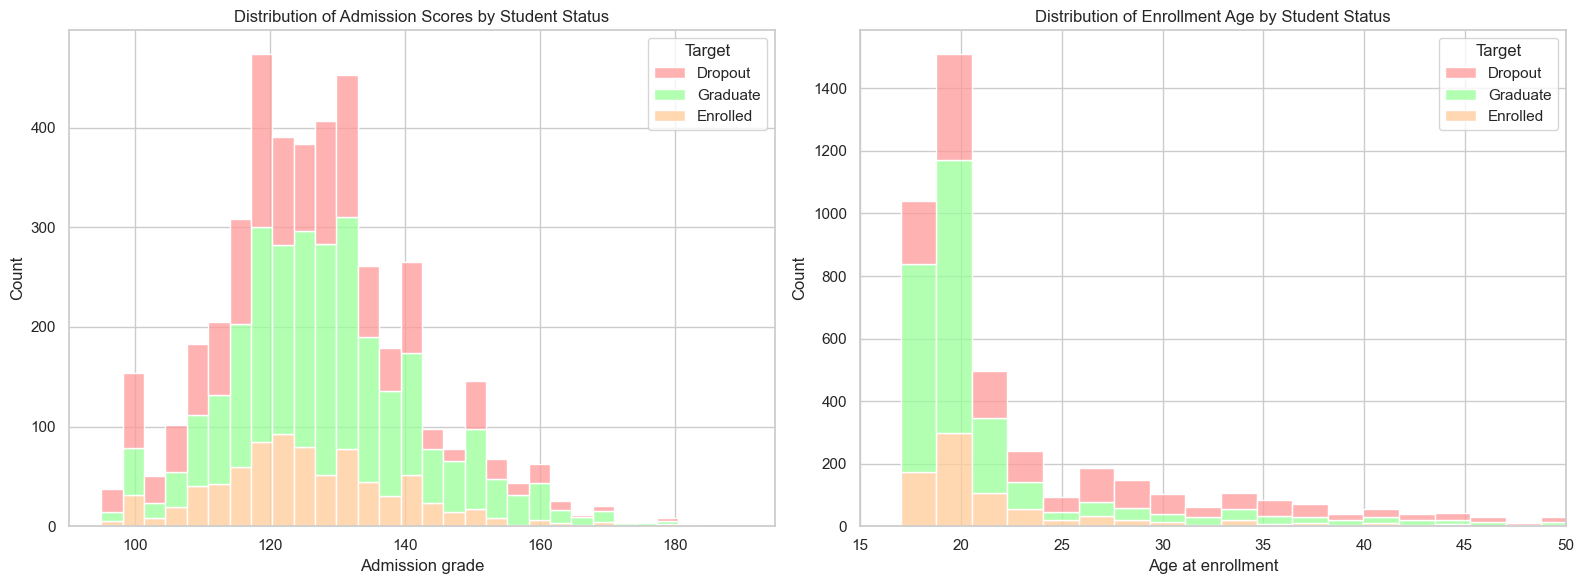

In [7]:
# 1.3 Bivariate analysis: How do age and admission scores influence dropout rates?
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of Admission Scores by Target
sns.histplot(data=data, x='Admission grade', hue='Target', multiple="stack", 
             palette={'Dropout': '#ff9999', 'Enrolled': '#ffcc99', 'Graduate': '#99ff99'}, 
             ax=axes[0], bins=30)
axes[0].set_title('Distribution of Admission Scores by Student Status', fontsize=12)

# Histogram of Enrollment Age by Target
sns.histplot(data=data, x='Age at enrollment', hue='Target', multiple="stack", 
             palette={'Dropout': '#ff9999', 'Enrolled': '#ffcc99', 'Graduate': '#99ff99'}, 
             ax=axes[1], bins=30)
axes[1].set_title('Distribution of Enrollment Age by Student Status', fontsize=12)
axes[1].set_xlim(15, 50) # We've narrowed down the age range for better visibility

plt.tight_layout()
plt.show()

##### Bivariate Analysis: Age and Admission Grade vs Target

**Admission Grade:**
Most students cluster in the 110-140 range. For scores under 120, the dropout rate (red) is noticeably higher than the graduation rate. Once grades pass the 130 mark, the trend reverses completely, with graduates (green) taking a clear lead. Basically, a better entrance score is a strong indicator that the student will stick with the program.

**Age at Enrollment:**
The 18-20 age group makes up the vast majority of the dataset and shows the highest success rate. However, there's a sharp shift for older students: from age 25 onwards, dropouts heavily outnumber graduates. This makes sense, as older students usually have to balance their degree with jobs or family obligations, making them much more likely to abandon their studies.

##### **2. CORRELATION MATRIX AND FEATURE SELECTION**
To ensure model interpretability and avoid multicollinearity (which can confuse the model), we will calculate Pearson's correlation matrix for numerical variables. We will use a heatmap to identify and drop redundant variables (features that give the exact same information). Finally, we'll plot a bar chart to see which features provide the most information about our Target.

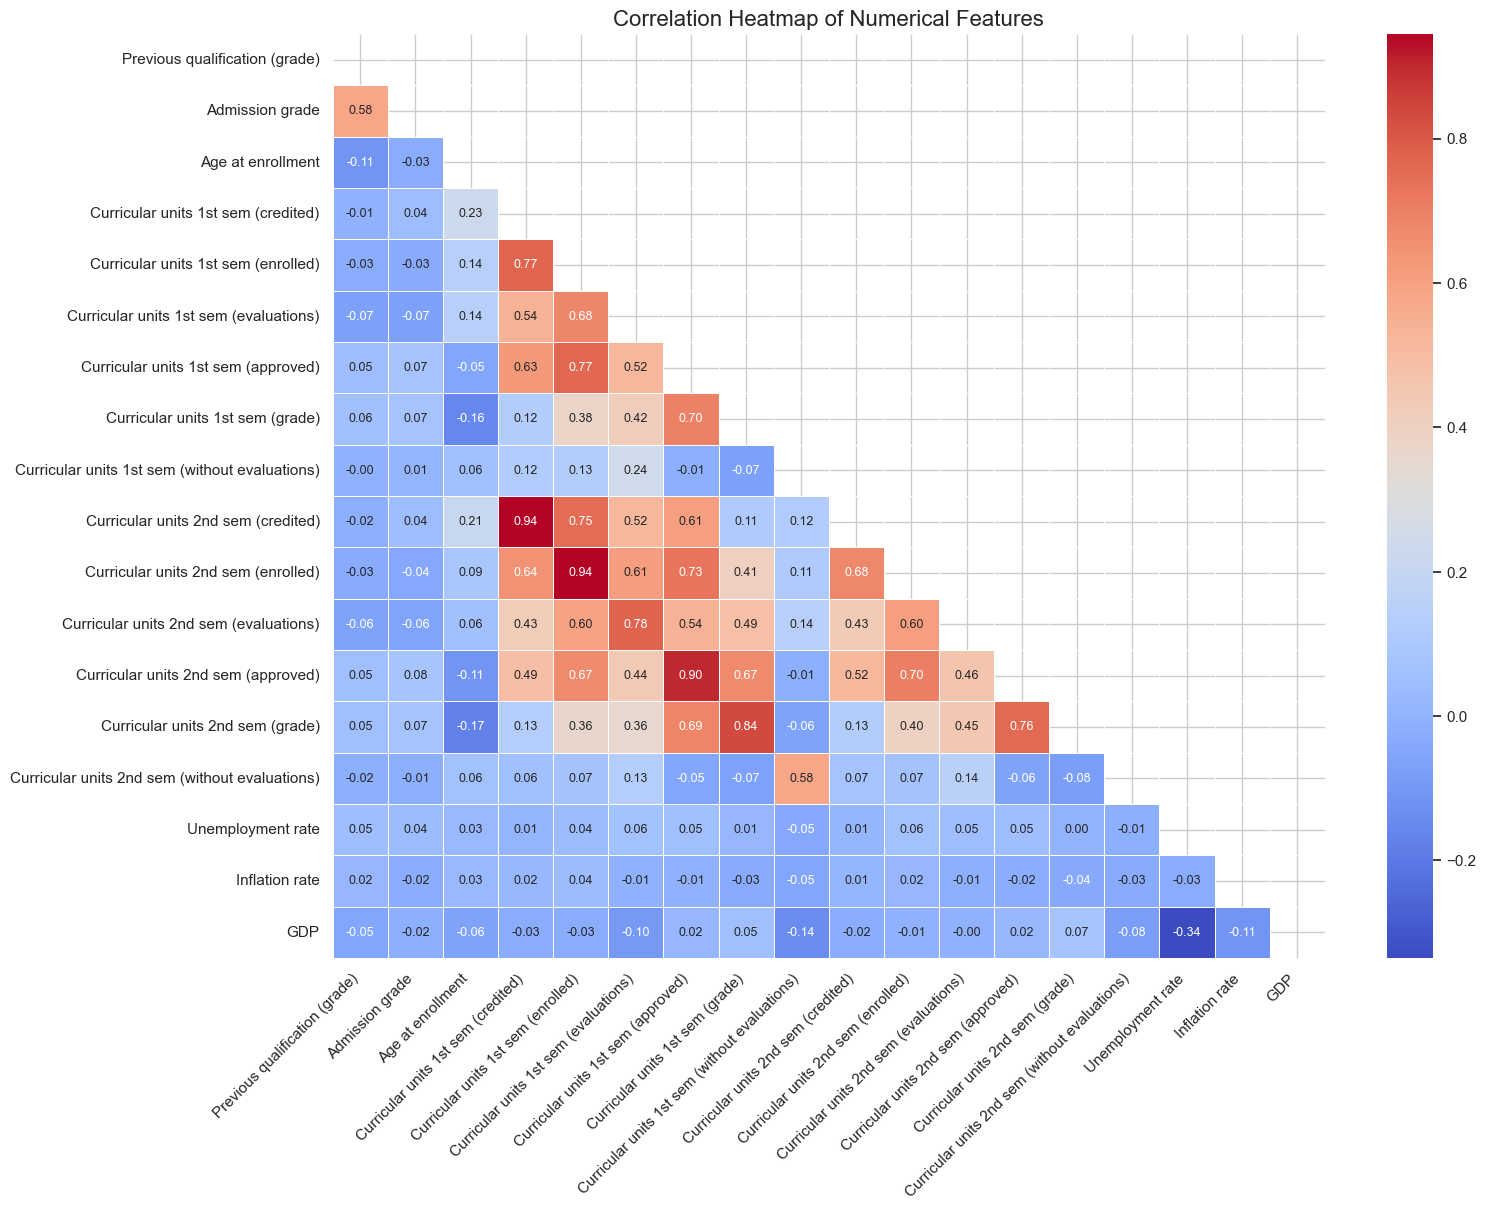

Highly correlated variables to be dropped (threshold > 0.85): 
['Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)']

Dataset updated. Fewer variables = Better interpretability.


C:\Users\marin\AppData\Local\Temp\ipykernel_14304\3792147908.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='mako')


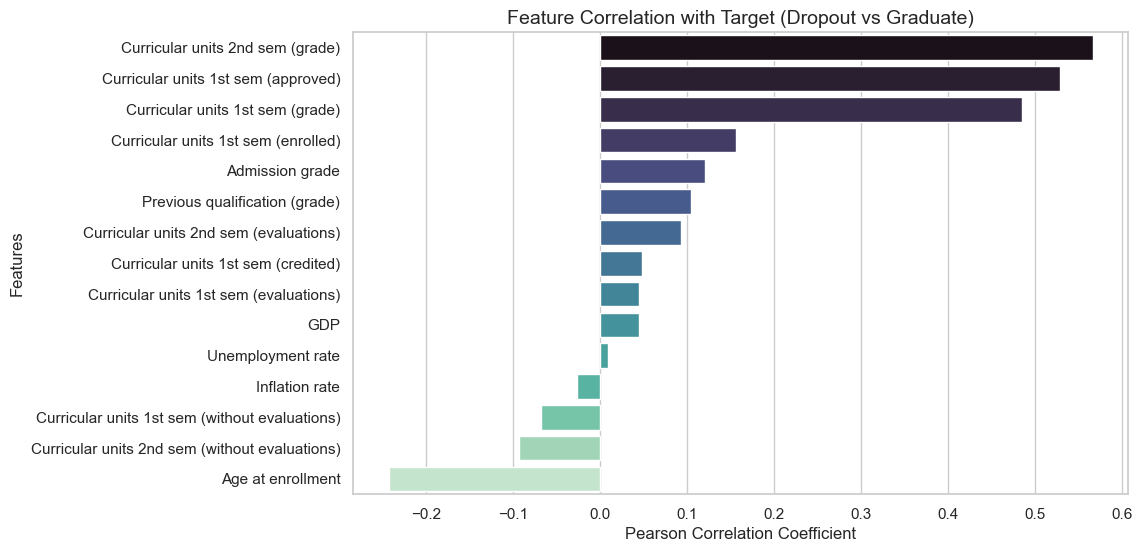

In [8]:
# 2.1 Heatmap of the correlation matrix
plt.figure(figsize=(16, 12))
corr_matrix = data[Numerical_data].corr()

# Create a mask to show only the lower triangle (cleaner visualization)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, annot_kws={"size": 9})
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

# 2.2 Identify and remove highly correlated variables (Threshold > 0.85)
# If two variables have > 0.85 correlation, they are redundant. We keep one and drop the other.
threshold = 0.85
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column].abs() > threshold)]

print(f"Highly correlated variables to be dropped (threshold > {threshold}): \n{to_drop}\n")

# Dropping the redundant variables from the dataset
data = data.drop(columns=to_drop)

# Updating the Numerical_data list
Numerical_data = [col for col in Numerical_data if col not in to_drop]
print("Dataset updated. Fewer variables = Better interpretability.")

# 2.3 Correlation with the Target
# Map Target to numerical values to calculate correlation (Dropout=0, Enrolled=1, Graduate=2)
data['Target_num'] = data['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})

# Calculate correlation of remaining numerical features with the numerical Target
target_corr = data[Numerical_data + ['Target_num']].corr()['Target_num'].drop('Target_num').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='mako')
plt.title('Feature Correlation with Target (Dropout vs Graduate)', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

# Remove the temporary numerical target column
data = data.drop(columns=['Target_num'])

##### **3. NOVELTY FACTOR: MACROECONOMIC VARIABLES VS DROPOUT**
We visually investigate how external macroeconomic factors (Inflation, GDP, and Unemployment rate) behave against the student's status. This helps us understand if a bad economic context influences the abandonment of studies.

C:\Users\marin\AppData\Local\Temp\ipykernel_14304\2630813839.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=data, x='Target', y=col, palette=palette_colors, order=['Dropout', 'Enrolled', 'Graduate'])
C:\Users\marin\AppData\Local\Temp\ipykernel_14304\2630813839.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=data, x='Target', y=col, palette=palette_colors, order=['Dropout', 'Enrolled', 'Graduate'])
C:\Users\marin\AppData\Local\Temp\ipykernel_14304\2630813839.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

 

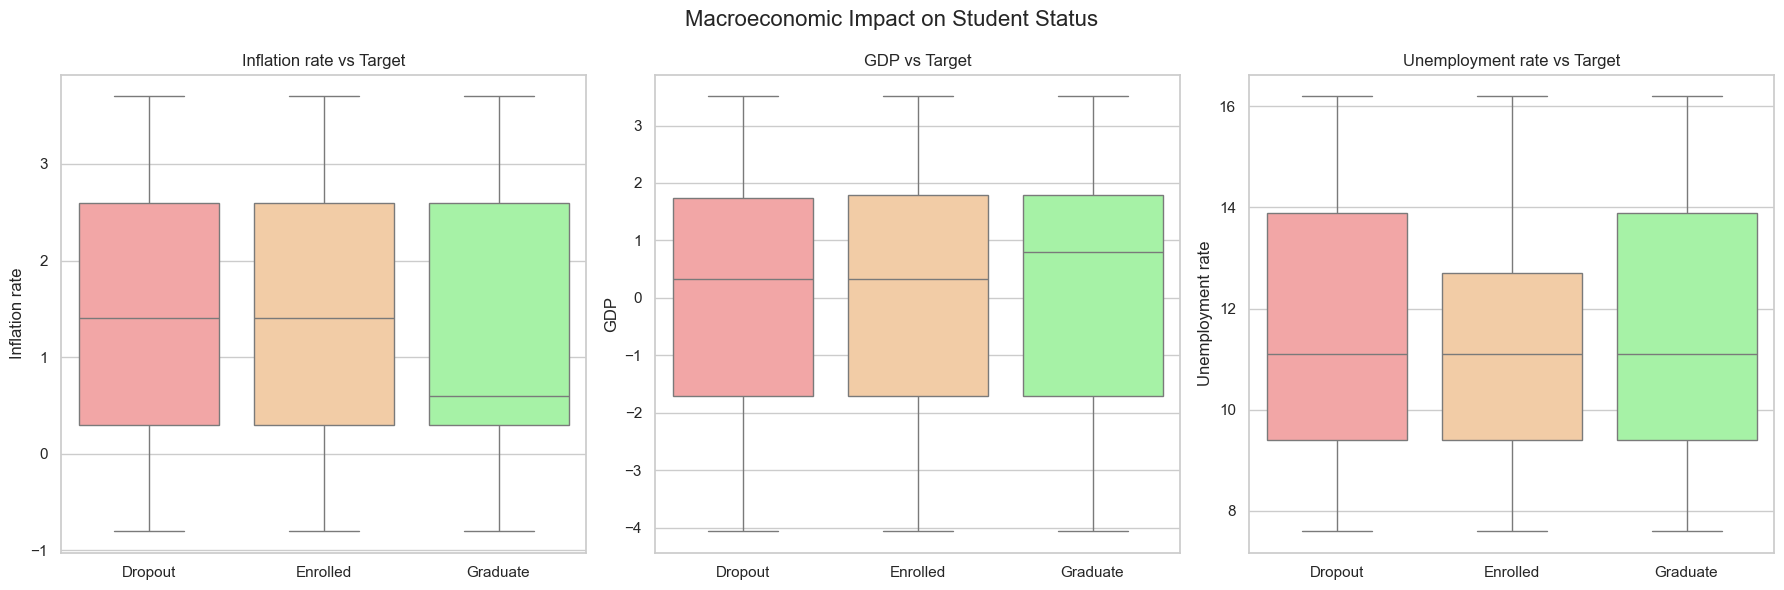

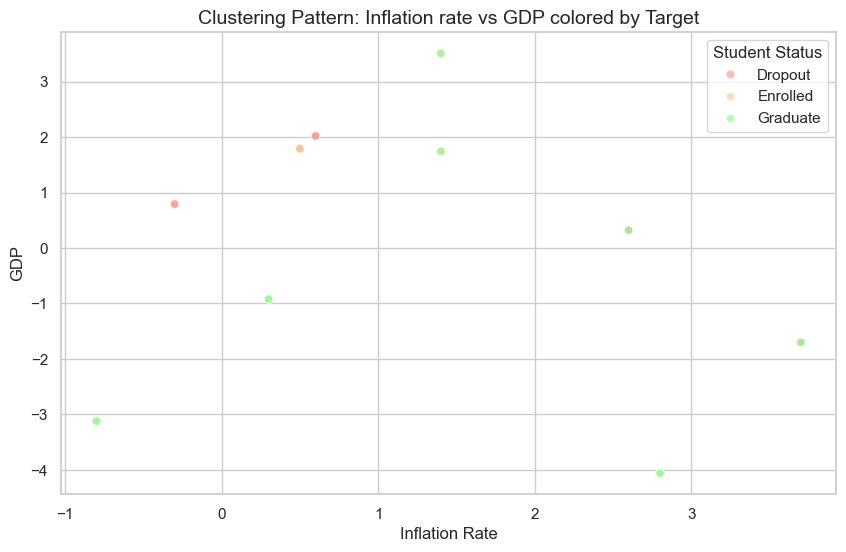

In [9]:
# 3.1 Boxplots for Macroeconomic variables vs Target
macro_vars = ['Inflation rate', 'GDP', 'Unemployment rate']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Macroeconomic Impact on Student Status', fontsize=16)

palette_colors = {'Dropout': '#ff9999', 'Enrolled': '#ffcc99', 'Graduate': '#99ff99'}

for i, col in enumerate(macro_vars):
    sns.boxplot(ax=axes[i], data=data, x='Target', y=col, palette=palette_colors, order=['Dropout', 'Enrolled', 'Graduate'])
    axes[i].set_title(f'{col} vs Target', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# 3.2 Scatter plot to find clustering patterns between Inflation and GDP
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Inflation rate', y='GDP', hue='Target', 
                palette=palette_colors, alpha=0.7, hue_order=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Clustering Pattern: Inflation rate vs GDP colored by Target', fontsize=14)
plt.xlabel('Inflation Rate')
plt.ylabel('GDP')
plt.legend(title='Student Status')
plt.show()

##### CONCLUSIONS REGARDING THE PATTERNS IDENTIFIED:
1. **Curricular Redundancy:** There is a very high correlation between several 1st and 2nd-semester variables (like Curricular units enrolled vs evaluations). We can drop these overlapping features to make the model simpler to interpret without losing predictive power.

2. **Academic Impact:** As expected, the number of approved curricular units and the grades obtained are the variables with the strongest positive correlation to student graduation. 
3. **Macroeconomic Influence (Novelty Factor):** Looking at the boxplots, dropouts tend to occur more frequently in periods with higher unemployment rates and lower GDP. This suggests that external economic conditions might play an important role in a student's decision to leave university.

## Dataset Preprocessing

In [10]:
# Display the first few rows of the dataset
pd.set_option('display.max_columns', None) # To see all the columns
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,10,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [11]:
# Display summary statistics of the dataset
data.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,10.960895,11.032324,126.978119,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,23.265145,0.024864,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,8.063291,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,26.418253,25.263040,14.482001,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,7.587816,0.155729,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,3.947951,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,0.000000,0.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,4.000000,4.000000,117.900000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,6.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,5.000000,7.000000,126.100000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,8.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,9.000000,9.000000,134.800000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,10.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,194.000000,195.000000,190.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,1.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,33.000000,18.571429,12.000000,16.200000,3.700000,3.510000


Numerical features: Previous qualification (grade), Admission grade, Age at enrollment, Curricular units 1st sem (c), Curricular units 1st sem (en), Curricular units 1st sem (ev), Curricular units 1st sem (ap), Curricular units 1st sem (gr), Curricular units 1st sem (we), Curricular units 2nd sem (c), Curricular units 2nd sem (en), Curricular units 2nd sem (ev), Curricular units 2nd sem (ap), Curricular units 2nd sem (gr), Curricular units 2nd sem (we), Unemployment rate, Inflation rate, GDP

Categorical features: Marital status, Application mode, Application order, Course, Daytime/evening, Previous qualification, Nacionality, Mother's qualification, Father's qualification, Mother's occupation, Father's occupation, Displaced, Educational special needs, Debtor, Tuition fees up to date, Gender, Scholarship holder, International, Target

In [12]:
Numerical_data = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]
Categorical_data = [
    'Marital status',
    'Application mode',
    'Application order',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International'
]

### INPUTATION OF VALUES

In [13]:
# Search of Null values

null_counts = data.isnull().sum().sum()
print('Number of null values in the whole dataset:', null_counts)

Number of null values in the whole dataset: 0


To analyze the distribution of the data and choose the outliers that should be eliminated, we must use only numerical variables, because if we use categorical variables, we would probably eliminate data that are not atypical, since, for example, nationality is represented by an identification number that varies a lot.

Previous qualification (grade)
Admission grade
Age at enrollment: Since the vast majority of students are of similar ages, those who are older tend to be more responsible, usually have more obligations, and enroll in fewer subjects, etc. Therefore, outliers are eliminated as they are exceptional cases. 
Curricular units 1st sem (enrolled)
Curricular units 1st sem (approved)
Curricular units 1st sem (grade)
Curricular units 1st sem (without evaluations)
Curricular units 2nd sem (enrolled)
Curricular units 2nd sem (approved)
Curricular units 2nd sem (grade)
Curricular units 2nd sem (without evaluations)
Unemployment rate
Inflation rate
GDP

In [14]:
data_to_process = ['Previous qualification (grade)','Admission grade', 'Age at enrollment', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']

we don't need to remove or input because there are not null values

KeyError: 'Curricular units 2nd sem (enrolled)'

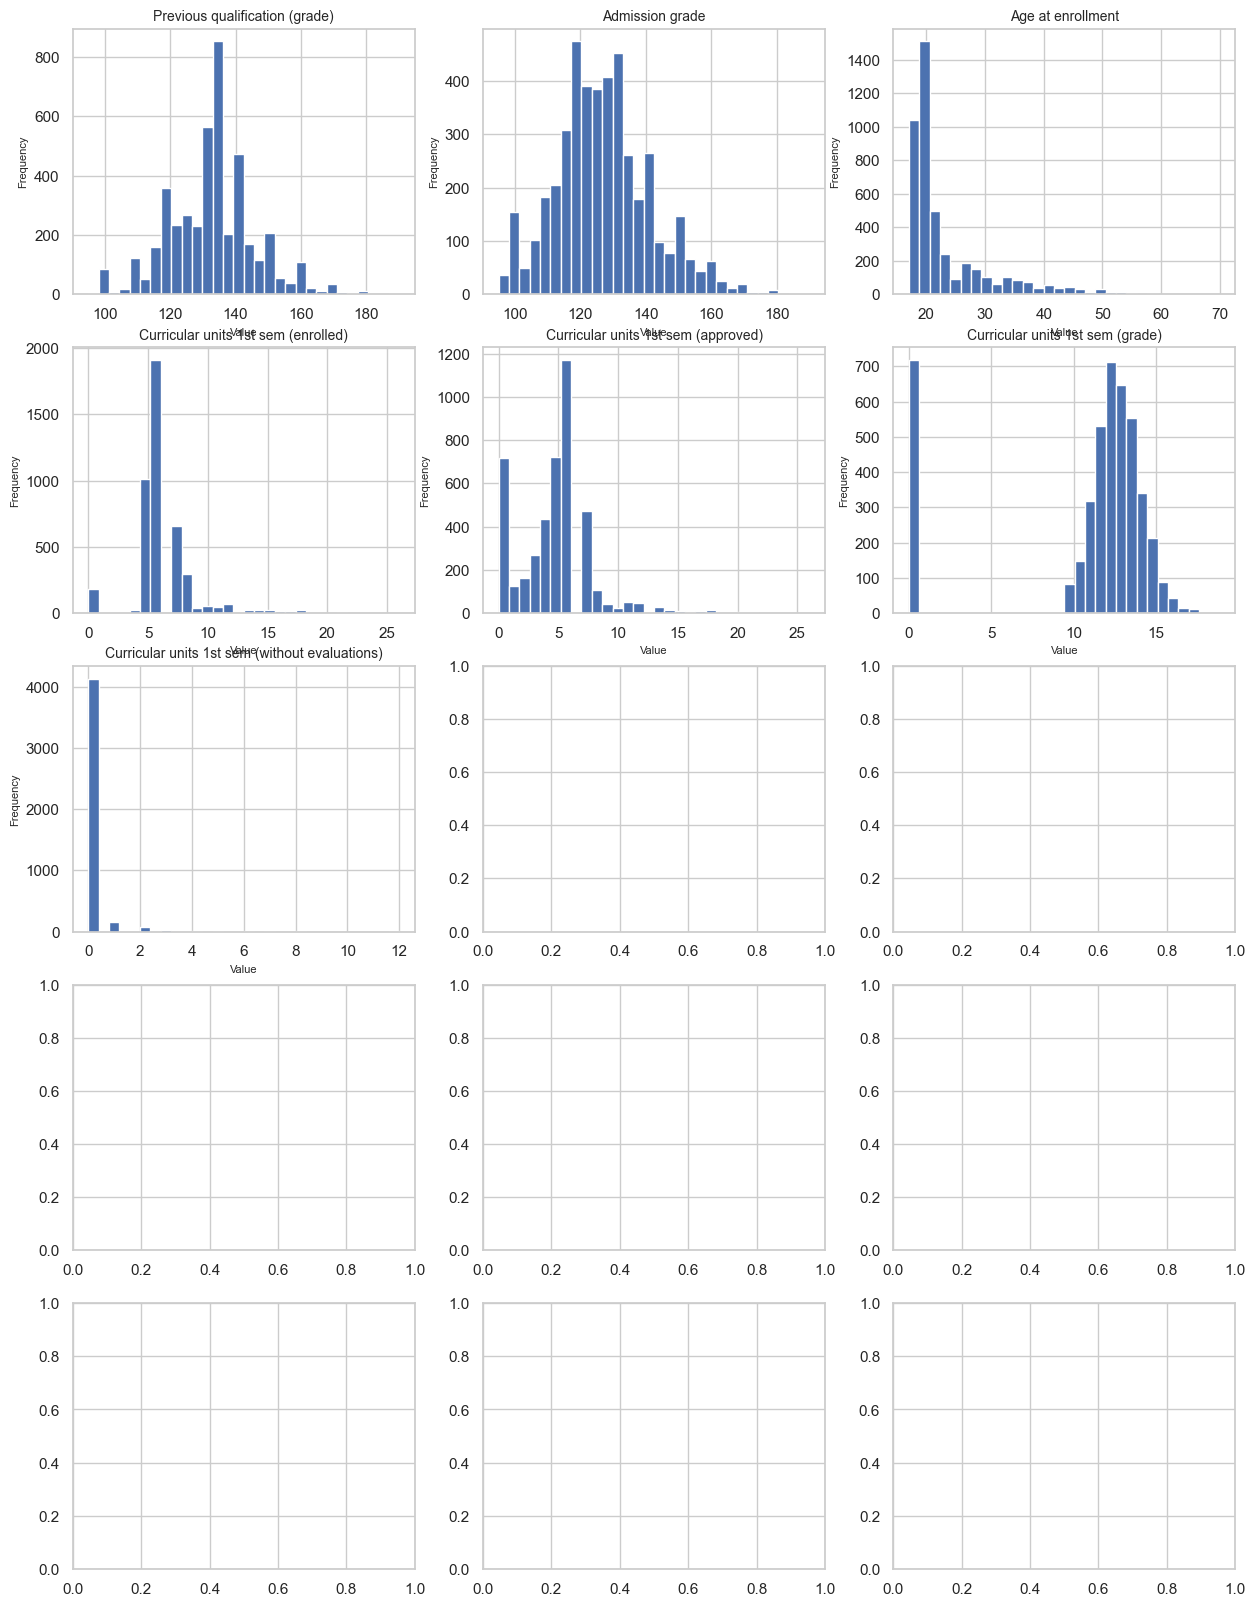

In [15]:
numeric_cols = data_to_process

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(data[col], bins=30)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value', fontsize=8)
    axes[i].set_ylabel('Frequency', fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### OUTLIERS MANAGEMENT

For this dataset, it's extremely recomended to use IQR over Z-score because the presence of extremely outliers (it's very sensible) and descrete features, the inexistance of normality (mean and normal desviation)(z-score asumes normality) and because IQR doesn't need normality (it's robust over asimetry)

In [79]:
for col in data_to_process:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    print(f"{col}: {outliers.shape[0]} outliers detectados")

Previous qualification (grade): 179 outliers detectados
Admission grade: 86 outliers detectados
Age at enrollment: 441 outliers detectados
Curricular units 1st sem (enrolled): 424 outliers detectados
Curricular units 1st sem (approved): 180 outliers detectados
Curricular units 1st sem (grade): 726 outliers detectados
Curricular units 1st sem (without evaluations): 294 outliers detectados
Curricular units 2nd sem (enrolled): 369 outliers detectados
Curricular units 2nd sem (approved): 44 outliers detectados
Curricular units 2nd sem (grade): 877 outliers detectados
Curricular units 2nd sem (without evaluations): 282 outliers detectados
Unemployment rate: 0 outliers detectados
Inflation rate: 0 outliers detectados
GDP: 0 outliers detectados


Before removing rows with outliers, a box plot is drawn to visually analyze the behavior and how far away the outliers are located.

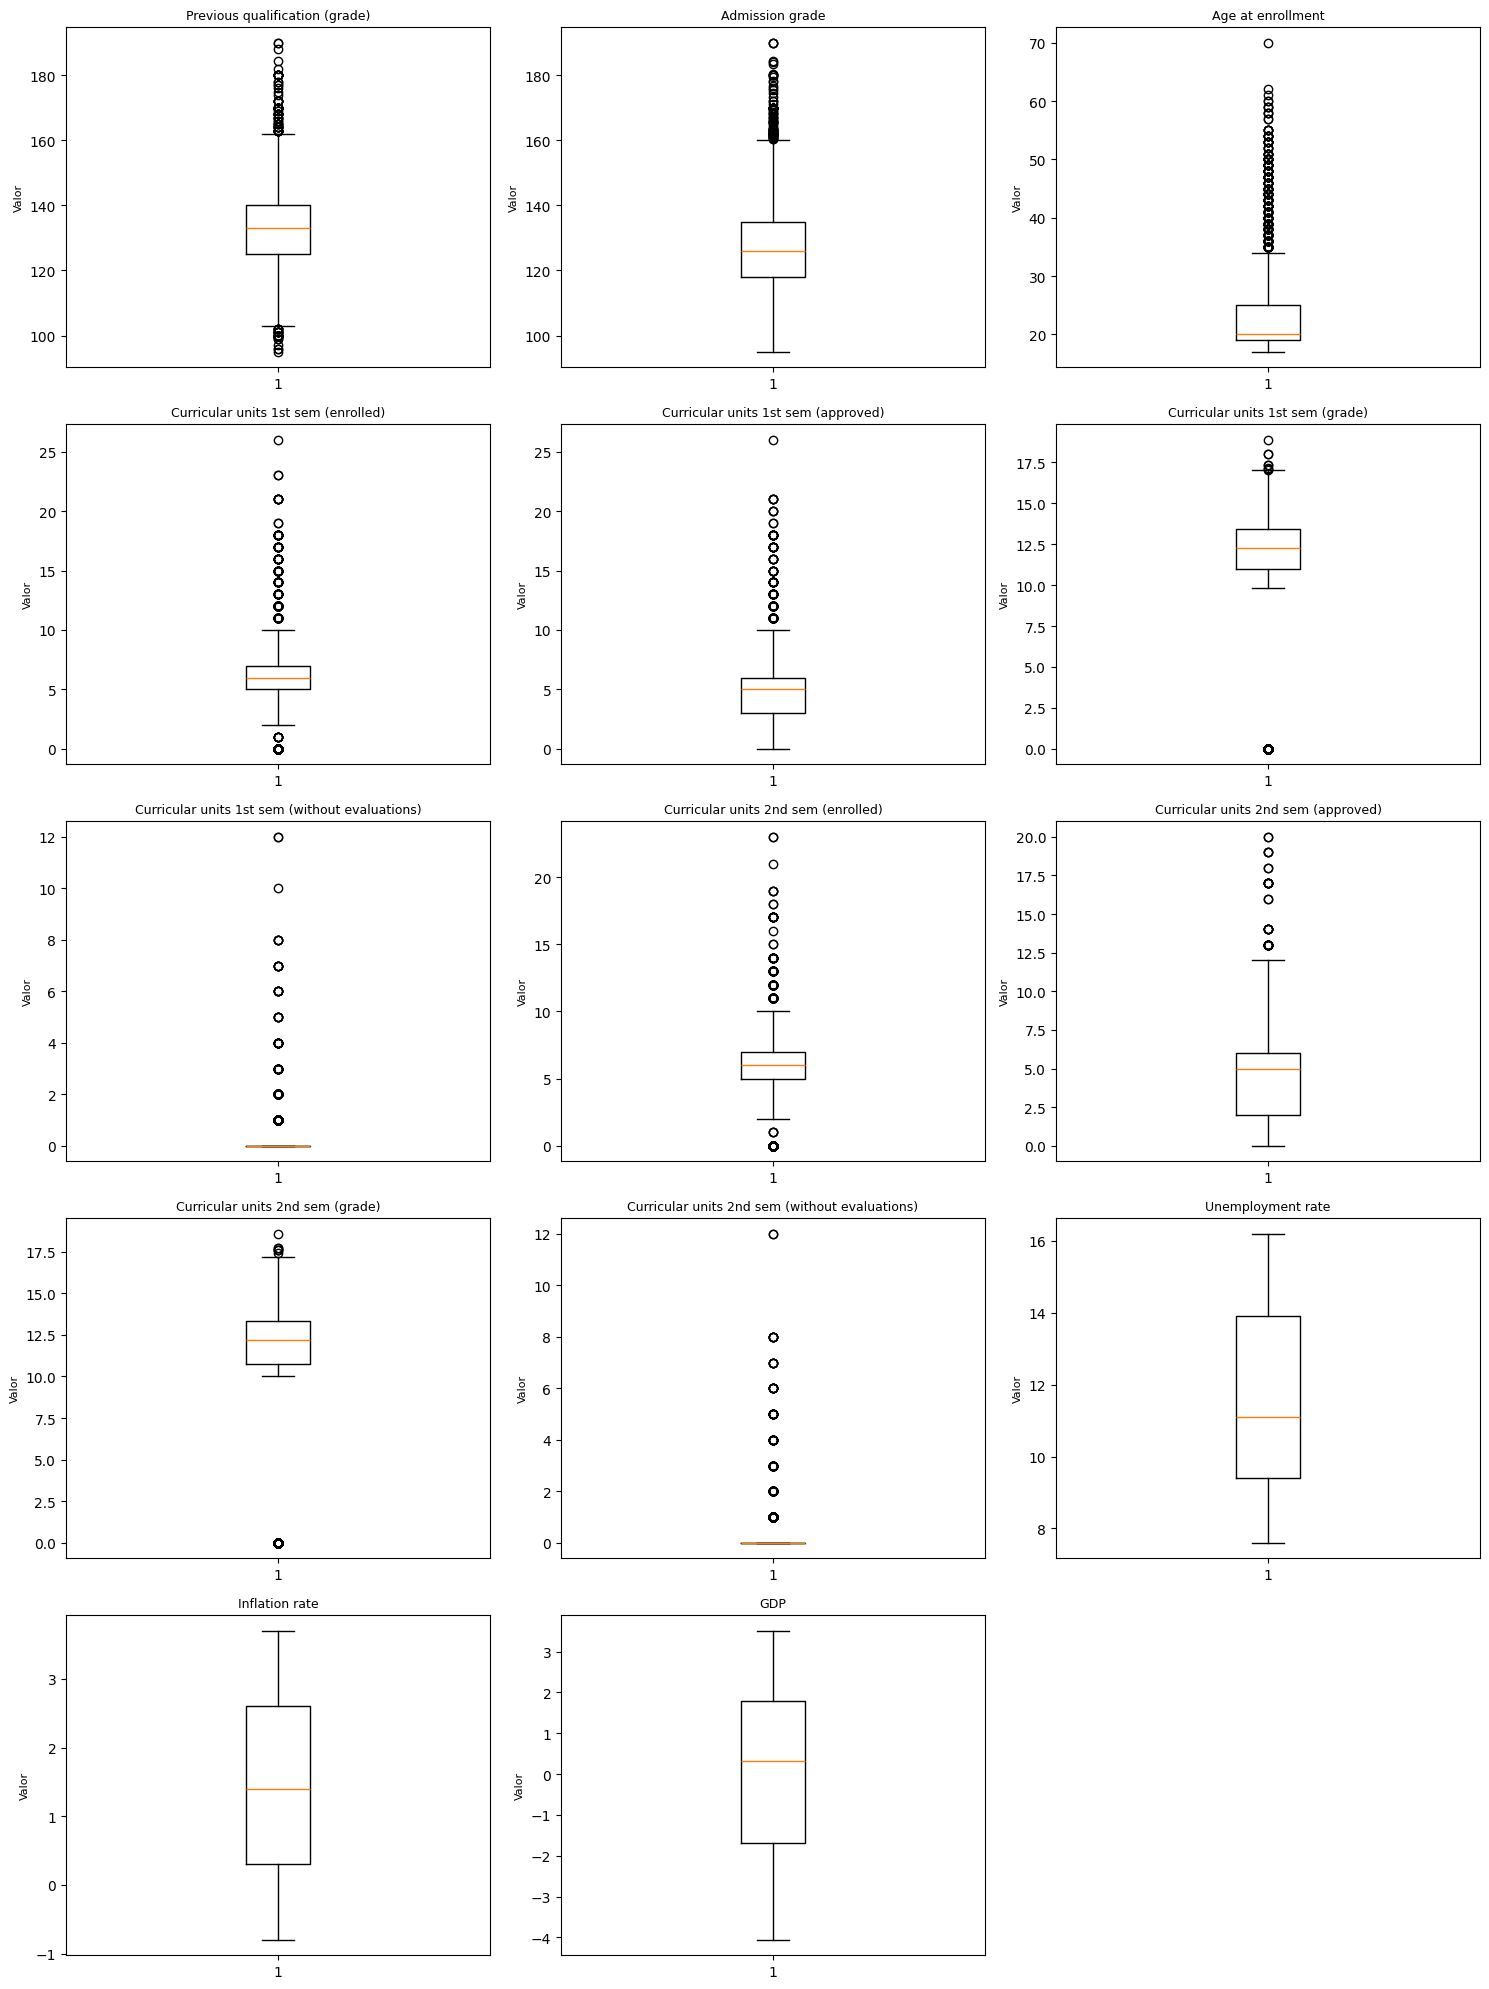

In [80]:
# Definir tamaño de la cuadrícula
n_cols = 3
n_rows = math.ceil(len(data_to_process) / n_cols)

# Crear figura y ejes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

# Dibujar boxplots
for i, col in enumerate(data_to_process):
    axes[i].boxplot(data[col], vert=True, showfliers=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Valor', fontsize=8)

# Eliminar subplots vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [81]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] >= lower) & (df[column] <= upper)]

data_clean = data.copy()

for col in data_to_process:
    data_clean = remove_outliers_iqr(data_clean, col)

print("Filas originales:", data.shape[0])
print("Filas tras eliminar outliers:", data_clean.shape[0])

data = data_clean

Filas originales: 4424
Filas tras eliminar outliers: 2513


In [82]:
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
6,1,1,1,9500,1,1,142.0,1,19,38,7,10,128.4,1,0,0,1,0,1,18,0,0,7,9,7,13.300000,0,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
8,1,1,3,9238,1,1,137.0,62,1,1,9,9,129.3,0,0,0,1,0,1,21,1,0,6,8,6,13.875000,0,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,9238,1,1,138.0,1,1,19,4,7,123.0,1,0,1,0,0,0,18,0,0,6,9,5,11.400000,0,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


### STANDARIZATION

    Even though categorical features are already represented as numbers, they remain categorical, so we use one-hot-encoding to avoid artificial ordinal relationships between data whose numbers have no relation.

    Before doing the data standarization, its needed to split the data to prevent data leakage. That way, we apply OneHotEncoder and StandardScaler to training and validaiton sets individually.

In [83]:
# Standarization of categorical features (One-Hot Encoding)

#Separate variables x and y
X = data.drop(columns=['Target'])
y = data['Target']

#Do the split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

encoded_train = encoder.fit_transform(X_train[Categorical_data])
encoded_test = encoder.transform(X_test[Categorical_data])

#Convert into DataFrame restoring the column names and original indexes
encoded_train_df = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(Categorical_data), index=X_train.index)
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(Categorical_data), index=X_test.index)

#Replace the categorical columns (original ones) with the new ones (encoded)
X_train = pd.concat([X_train.drop(columns=Categorical_data), encoded_train_df], axis=1)
X_test = pd.concat([X_test.dop(columns=Categorical_data), encoded_test_df], axis=1)


In [84]:
# Standarization of numerical features (StandardScaler)

scaler = StandardScaler()
X_train[Numerical_data] = scaler.fit_transform(X_train[Numerical_data])
X_test[Numerical_data] = scaler.fit_transform(X_test[Numerical_data])